### Calculating Horizontal Head Angle

ARKit uses Euler matrices to express rotation in 3D space. We get three transform matrices: one for the head and one for each eye. The head transform gives us the location and orientation of the head in camera space. Which means that if we want the angle of the head relative to the camera we can just compare the angles of the Z axes of the head and the camera. Specifically, we can project the head's Z axis onto the Z/X plane of the camera space and then calculate the difference in angle between the two Z axes and then add 180 degrees. So, we can pluck out the Z and X component of the head transform and calculate the angle using

$$
Z_c \cdot Z_h  = \| \mathbf{Z_c} \| \| \mathbf{Z_h} \| cos(\theta')
$$

where $Z_c$ and $Z_h$ are the unit $Z$ vectors of the camera and head space, and $\theta'$ is the measured angle. Then 

$$
\theta = \theta' + \pi
$$

is the calculated head angle.


In [1]:
from dataclasses import dataclass
from enum import Enum
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pydantic import BaseModel

In [2]:
class Transforms(BaseModel):
    head: list[list[list[float]]]
    left_eye: list[list[list[float]]]
    right_eye: list[list[list[float]]]

In [3]:
DATA_DIR = Path("./data")
TRANSFORMS_DIR = DATA_DIR / "transforms"

In [4]:
session_id = "3ba72673-499e-4c31-ba51-e74ba9dbf4a5"
transforms_path = TRANSFORMS_DIR / f"{session_id}.json"
transforms = Transforms.model_validate_json(transforms_path.read_bytes())

In [38]:


def _extract_head_angle(transforms: list[list[list[float]]]) -> np.ndarray:
    transforms_array = np.array(transforms)
    unit_z_4 = np.array([0, 0, 1, 0])
    transformed_z = transforms_array @ unit_z_4.T
    two_d = transformed_z[:, [0, 2]]
    unit_z_2 = np.array([0, 1])
    head_angle_radians = np.arccos(np.dot(two_d, unit_z_2) / np.linalg.norm(two_d)) + np.pi
    head_angle = head_angle_radians * 180 / np.pi
    return head_angle


In [39]:
_extract_head_angle(transforms.head)

array([268.49632237, 268.49682804, 268.49737855, ..., 268.50295244,
       268.5030548 , 268.503157  ], shape=(1442,))

In [33]:
transforms.head

[[[0.9967263, 0.029258184, 0.07536911, 0.0],
  [-0.0325241, 0.9985679, 0.042475566, 0.0],
  [-0.07401844, -0.044787813, 0.9962506, 0.0],
  [0.015144211, -0.018521558, -0.35723817, 1.0]],
 [[0.99647915, 0.029413387, 0.078513466, 0.0],
  [-0.032984562, 0.99846107, 0.044582173, 0.0],
  [-0.07708133, -0.04701494, 0.99591565, 0.0],
  [0.015538166, -0.018164376, -0.35719872, 1.0]],
 [[0.99627066, 0.027999653, 0.081612915, 0.0],
  [-0.031916242, 0.9983805, 0.047086928, 0.0],
  [-0.08016237, -0.04951608, 0.995551, 0.0],
  [0.01651336, -0.017560445, -0.3570794, 1.0]],
 [[0.9966125, 0.02621008, 0.07795086, 0.0],
  [-0.029998777, 0.9984043, 0.047836393, 0.0],
  [-0.07657272, -0.050012782, 0.99580866, 0.0],
  [0.01647888, -0.017294962, -0.35708, 1.0]],
 [[0.9971592, 0.024502443, 0.07122606, 0.0],
  [-0.027987344, 0.9984381, 0.048348267, 0.0],
  [-0.069930196, -0.05020435, 0.9962875, 0.0],
  [0.015766822, -0.017318778, -0.35717303, 1.0]],
 [[0.99764687, 0.021986755, 0.064939864, 0.0],
  [-0.0253612

In [9]:
transforms_array = np.array(transforms.head)
unit_z = np.array([0, 1])

In [12]:
transformed_z = transforms_array @ unit_z.T
transformed_z

array([[ 0.07536911,  0.04247557,  0.9962506 , -0.35723817],
       [ 0.07851347,  0.04458217,  0.99591565, -0.35719872],
       [ 0.08161291,  0.04708693,  0.995551  , -0.3570794 ],
       ...,
       [ 0.12721758, -0.00560399,  0.9918589 , -0.3691281 ],
       [ 0.12780327, -0.00406586,  0.9917911 , -0.36911145],
       [ 0.12835558, -0.00306893,  0.9917234 , -0.36898497]],
      shape=(1442, 4))

In [13]:
two_d = transformed_z[:, [0, 2]]
two_d

array([[0.07536911, 0.9962506 ],
       [0.07851347, 0.99591565],
       [0.08161291, 0.995551  ],
       ...,
       [0.12721758, 0.9918589 ],
       [0.12780327, 0.9917911 ],
       [0.12835558, 0.9917234 ]], shape=(1442, 2))

In [23]:
unit_z_2 = np.array([0, 2])
dot = np.dot(two_d, unit_z_2)

In [24]:
dot

array([1.9925012, 1.9918313, 1.991102 , ..., 1.9837178, 1.9835822,
       1.9834468], shape=(1442,))

In [31]:

head_angle_radians = np.arccos(dot / np.linalg.norm(two_d)) + np.pi
head_angle = head_angle_radians * 180 / np.pi

In [32]:
head_angle

array([266.99160783, 266.99262021, 266.99372236, ..., 267.00488163,
       267.00508655, 267.00529117], shape=(1442,))

In [16]:
def _single_plot(angles: np.ndarray, title: str, ax: plt.Axes):
    ax.plot(angles)
    ax.set_title(title)
    ax.set_yticks([-60, -55, -45, -30, -15, 0, 15, 30, 45, 55, 60])
    ax.set_yticklabels(["-60°", "-55°", "-45°", "-30°", "-15°", "0°", "15°", "30°", "45°", "55°", "60°"])
    ax.grid(axis="y")

def plot_angles(angles: GazeAngles):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    _single_plot(angles.horizontal.left, "Left - Horizontal", axes[0][0])
    _single_plot(angles.vertical.left, "Left - Vertical", axes[1][0])
    _single_plot(angles.horizontal.right, "Right - Horizontal", axes[0][1])
    _single_plot(angles.vertical.right, "Right - Vertical", axes[1][1])


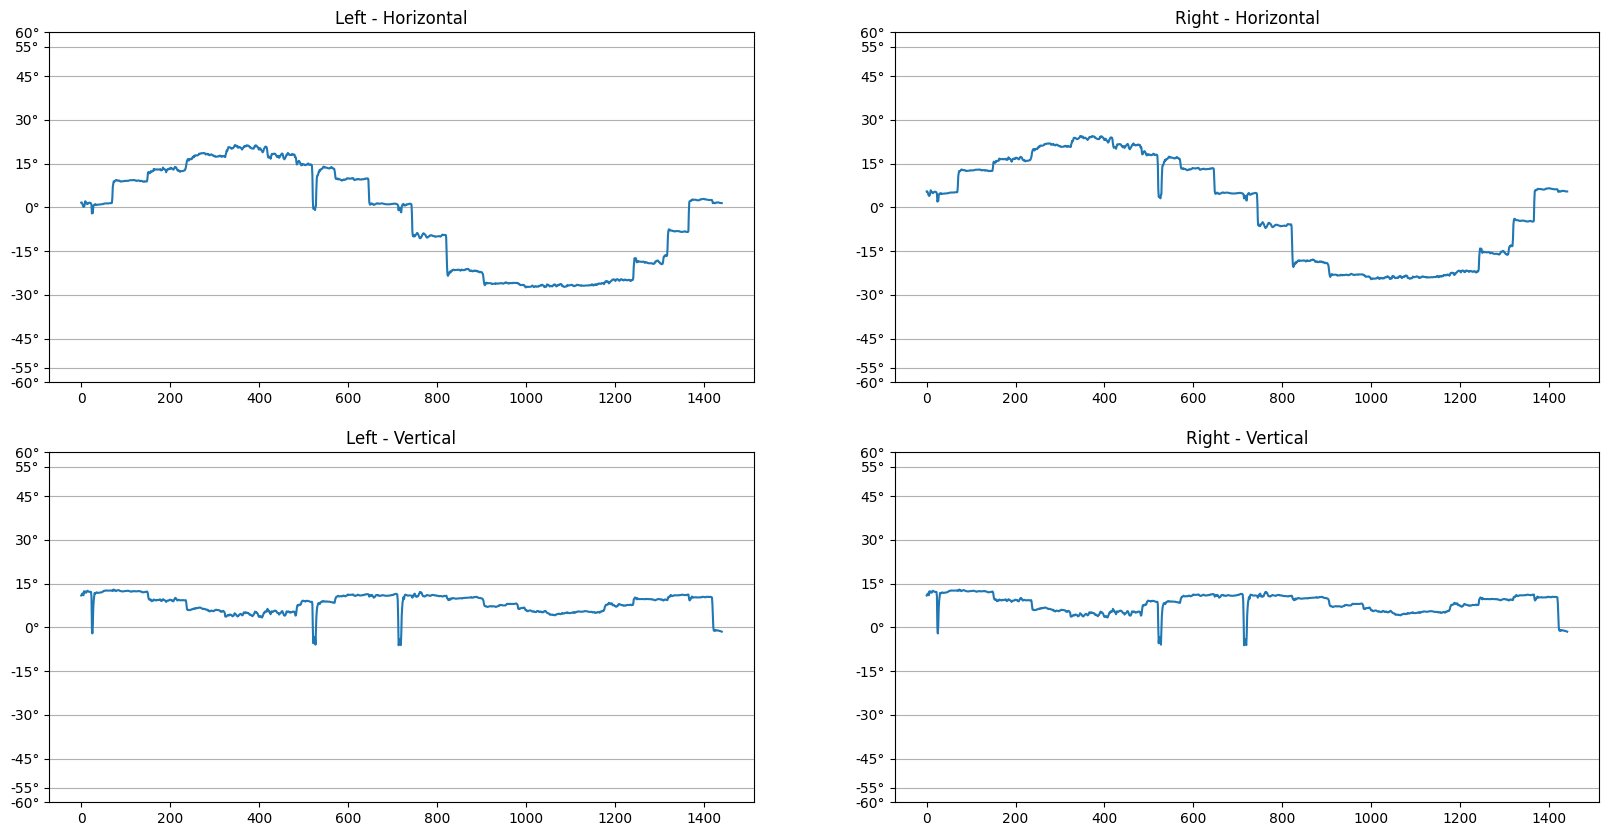

In [17]:
angles = extract_angle(transforms)
plot_angles(angles)

In [6]:
left_eye = np.array(transforms.left_eye)
left_eye.shape
 

(281, 4, 4)

In [9]:
left_eye[0]

array([[ 1.0000000e+00, -3.6035976e-06, -2.7245790e-04,  0.0000000e+00],
       [ 0.0000000e+00,  9.9991250e-01, -1.3225098e-02,  0.0000000e+00],
       [ 2.7248173e-04,  1.3225098e-02,  9.9991250e-01,  0.0000000e+00],
       [ 3.1966366e-02,  3.0724604e-02,  2.4759667e-02,  1.0000000e+00]])

In [8]:
left_eye[0].T

array([[ 1.0000000e+00,  0.0000000e+00,  2.7248173e-04,  3.1966366e-02],
       [-3.6035976e-06,  9.9991250e-01,  1.3225098e-02,  3.0724604e-02],
       [-2.7245790e-04, -1.3225098e-02,  9.9991250e-01,  2.4759667e-02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]])

In [12]:
left_eye[1]

array([[ 1.0000000e+00, -1.6913966e-06, -1.2695108e-04,  0.0000000e+00],
       [ 0.0000000e+00,  9.9991130e-01, -1.3322033e-02,  0.0000000e+00],
       [ 1.2696235e-04,  1.3322033e-02,  9.9991130e-01,  0.0000000e+00],
       [ 3.1966366e-02,  3.0724604e-02,  2.4759667e-02,  1.0000000e+00]])

In [14]:
unit_z = np.array([0, 0, 1, 0])
transformed_z = left_eye @ unit_z.T
x_z = transformed_z[:, [0, 2]]
x_z.shape

(281, 2)

In [32]:
x_z

array([[-2.72457900e-04,  9.99912500e-01],
       [-1.26951080e-04,  9.99911300e-01],
       [-1.77437740e-05,  9.99913040e-01],
       [-3.96411100e-04,  9.99915800e-01],
       [-1.08230100e-03,  9.99932000e-01],
       [-1.35188120e-03,  9.99936500e-01],
       [-1.39017700e-03,  9.99937060e-01],
       [-1.24128940e-03,  9.99934500e-01],
       [-1.58554870e-03,  9.99930260e-01],
       [-1.89121790e-03,  9.99924200e-01],
       [-2.24943830e-03,  9.99925200e-01],
       [-2.53562230e-03,  9.99909800e-01],
       [-3.18111970e-03,  9.99878640e-01],
       [-2.91432930e-03,  9.99878700e-01],
       [-2.61662390e-03,  9.99862800e-01],
       [-2.49687560e-03,  9.99839600e-01],
       [-2.37905700e-03,  9.99830500e-01],
       [-2.52492730e-03,  9.99820950e-01],
       [-2.71837460e-03,  9.99815000e-01],
       [-2.63551860e-03,  9.99811700e-01],
       [-2.34066930e-03,  9.99802100e-01],
       [-2.36336420e-03,  9.99800560e-01],
       [-2.12856780e-03,  9.99808300e-01],
       [-2.

In [39]:
arc_tan = np.vectorize(math.atan)
x_over_z = x_z[:, 0] / x_z[:, 1]
angles_radians = -arc_tan(x_over_z)
angles_degrees = angles_radians * 180 / math.pi

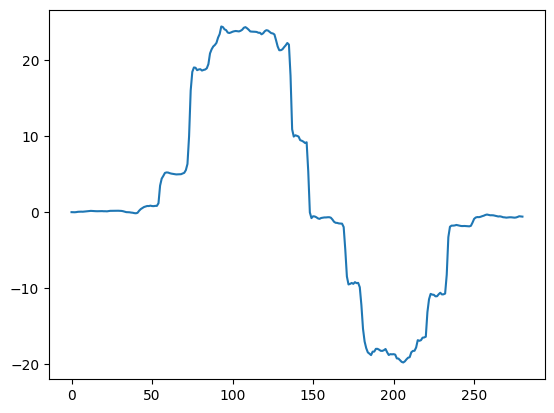

In [40]:
plt.plot(angles_degrees)